In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Paths
PROC_DIR = Path("..") / "data" / "processed"

# Load weekly features CSV
df = pd.read_csv(PROC_DIR / "covid_weekly_features.csv", parse_dates=["date"])

df.head()

,location,date,iso_code,continent,population,new_cases,new_deaths,rolling_7d_cases,rolling_7d_deaths,cases_per_million,deaths_per_million,case_fatality_rate
0,Afghanistan,2020-01-05,AFG,Asia,38928341.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,Afghanistan,2020-01-12,AFG,Asia,38928341.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,Afghanistan,2020-01-19,AFG,Asia,38928341.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,Afghanistan,2020-01-26,AFG,Asia,38928341.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,Afghanistan,2020-02-02,AFG,Asia,38928341.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [2]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("\nCountries:", df['location'].nunique())
print("Date Range:", df['date'].min(), "→", df['date'].max())

df.describe().T

Rows: 6488
Columns: 12

Countries: 210
Date Range: 2020-01-05 00:00:00 → 2020-09-20 00:00:00


,count,mean,min,25%,50%,75%,max,std
date,6488,2020-06-04 08:02:30.924784128,2020-01-05 00:00:00,2020-04-12 00:00:00,2020-06-07 00:00:00,2020-08-02 00:00:00,2020-09-20 00:00:00,NaN
population,6426.0,42928784.820884,809.0,1399491.0,8278737.0,29825968.0,1439323774.0,157508661.461308
new_cases,6488.0,4704.917848,-1594.0,2.0,82.0,980.25,640545.0,29205.019097
new_deaths,6488.0,146.749846,-1625.0,0.0,1.0,18.0,18302.0,799.262543
rolling_7d_cases,6464.0,4627.943608,-3081.857143,2.571429,78.0,949.321429,649090.333333,28964.335099
rolling_7d_deaths,6464.0,145.510855,-1116.0,0.0,1.0,17.285714,16741.428571,793.00204
cases_per_million,6385.0,1826.990628,0.0,24.09521,266.001241,1823.53408,42663.811236,3920.430156
deaths_per_million,6385.0,56.015821,0.0,0.0,4.562202,33.76591,1237.550828,142.165578
case_fatality_rate,6012.0,0.033847,0.0,0.005004,0.019829,0.043668,1.0,0.052442


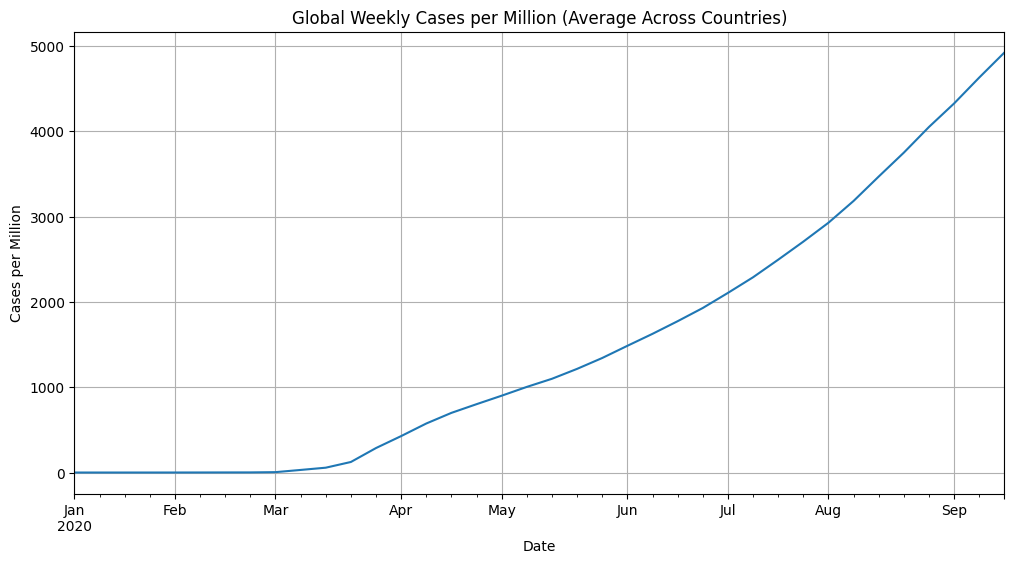

In [3]:
plt.figure(figsize=(12,6))
df.groupby("date")["cases_per_million"].mean().plot()
plt.title("Global Weekly Cases per Million (Average Across Countries)")
plt.ylabel("Cases per Million")
plt.xlabel("Date")
plt.grid(True)
plt.show()

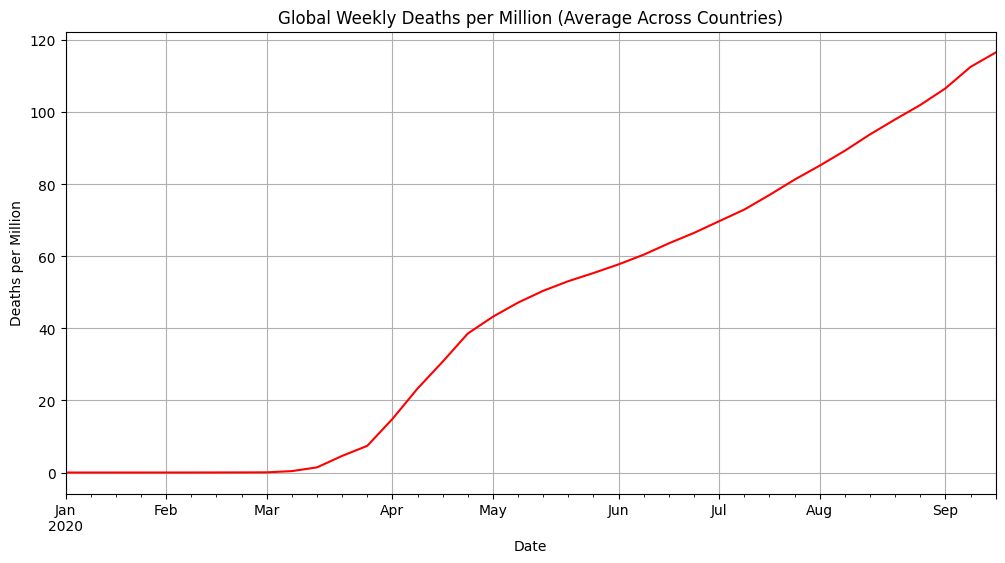

In [4]:
plt.figure(figsize=(12,6))
df.groupby("date")["deaths_per_million"].mean().plot(color="red")
plt.title("Global Weekly Deaths per Million (Average Across Countries)")
plt.ylabel("Deaths per Million")
plt.xlabel("Date")
plt.grid(True)
plt.show()

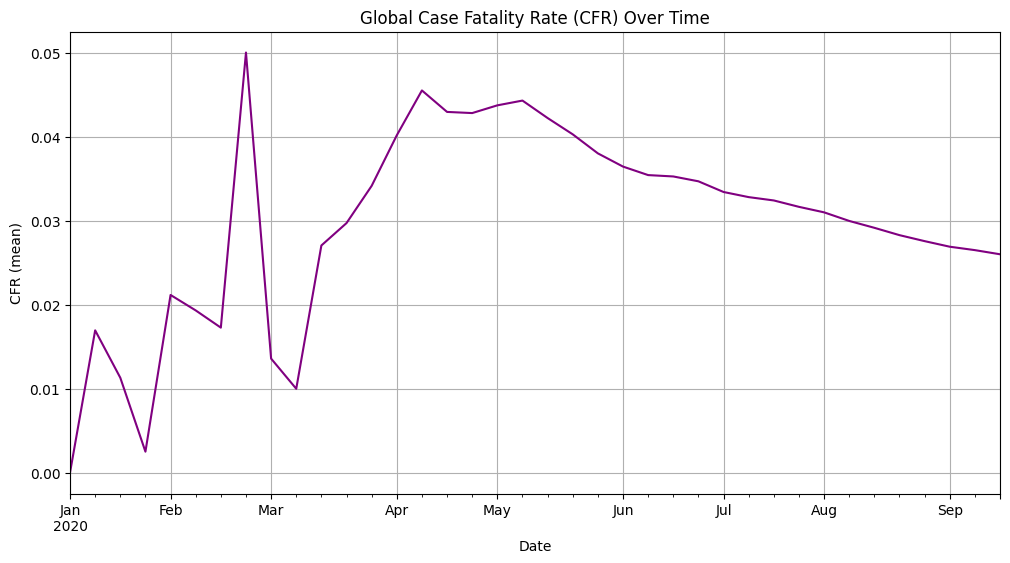

In [5]:
plt.figure(figsize=(12,6))
df.groupby("date")["case_fatality_rate"].mean().plot(color="purple")
plt.title("Global Case Fatality Rate (CFR) Over Time")
plt.ylabel("CFR (mean)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

In [6]:
peak_cases = df.groupby("date")["new_cases"].sum().idxmax()
peak_deaths = df.groupby("date")["new_deaths"].sum().idxmax()

print("📌 Peak global weekly cases:", peak_cases)
print("📌 Peak global weekly deaths:", peak_deaths)

📌 Peak global weekly cases: 2020-09-06 00:00:00
📌 Peak global weekly deaths: 2020-04-19 00:00:00


In [7]:
burden = (
    df.groupby("location")
      .agg({
          "cases_per_million": "max",
          "deaths_per_million": "max",
          "case_fatality_rate": "max"
      })
      .sort_values("deaths_per_million", ascending=False)
)

burden.head(10)

,cases_per_million,deaths_per_million,case_fatality_rate
location,,,
San Marino,21303.553539,1237.550828,0.132450
Peru,22941.148033,948.779149,0.050489
Belgium,8590.017133,857.405457,0.159692
Andorra,20242.024202,685.950948,0.067017
Spain,13689.294633,652.232735,0.121948
Bolivia,11141.152823,646.790135,0.081818
Brazil,21147.890000,638.847279,0.069932
Chile,23165.000969,638.149541,0.027548
Ecuador,7035.570927,625.968511,0.096065


Using columns for correlation: ['cases_per_million', 'deaths_per_million', 'case_fatality_rate', 'rolling_7d_cases', 'rolling_7d_deaths', 'new_cases', 'new_deaths']


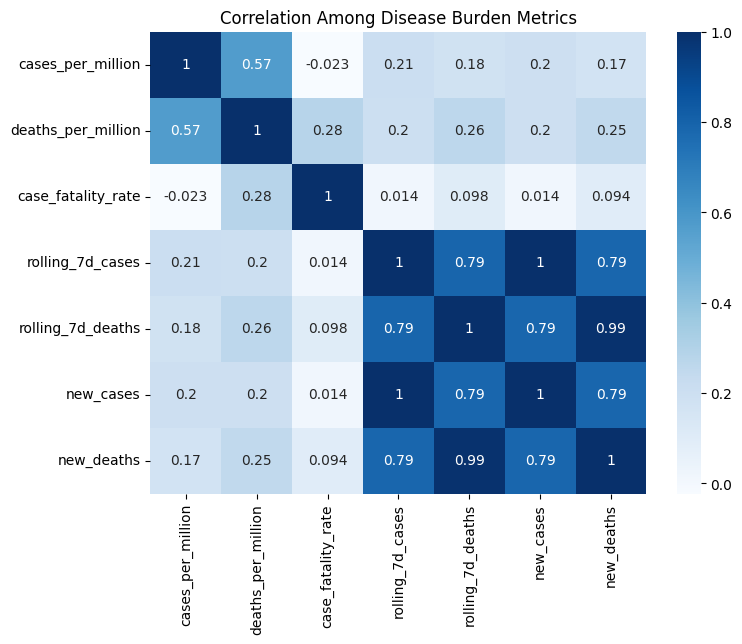

In [10]:
# Pick numeric columns that actually exist in the weekly dataset
candidate_cols = [
    "cases_per_million",
    "deaths_per_million",
    "case_fatality_rate",
    "rolling_7d_cases",
    "rolling_7d_deaths",
    "new_cases",
    "new_deaths",
]

cols = [c for c in candidate_cols if c in df.columns]
print("Using columns for correlation:", cols)

corr_data = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_data, annot=True, cmap="Blues")
plt.title("Correlation Among Disease Burden Metrics")
plt.show()

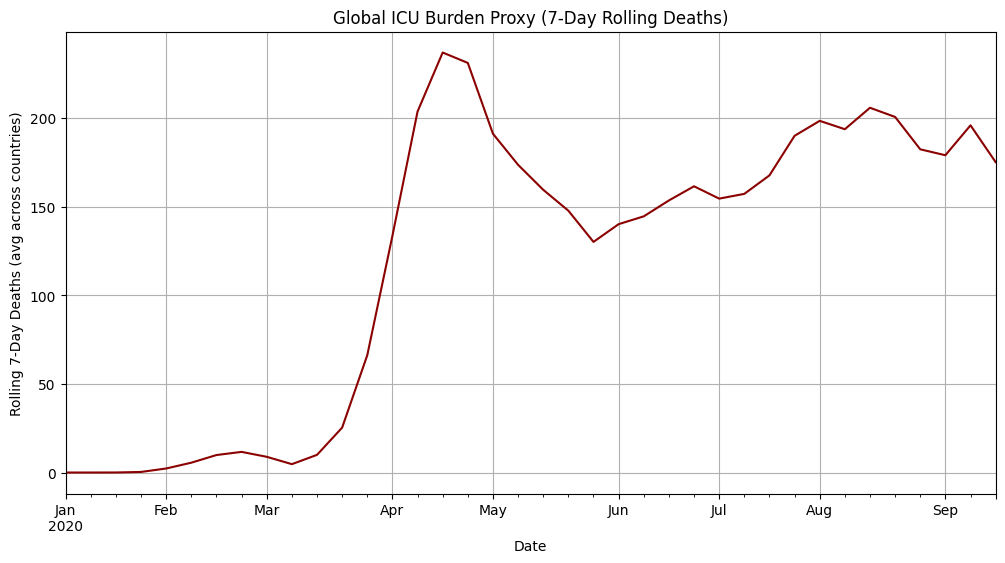

In [11]:
plt.figure(figsize=(12,6))
df.groupby("date")["rolling_7d_deaths"].mean().plot(color="darkred")
plt.title("Global ICU Burden Proxy (7-Day Rolling Deaths)")
plt.ylabel("Rolling 7-Day Deaths (avg across countries)")
plt.xlabel("Date")
plt.grid(True)
plt.show()

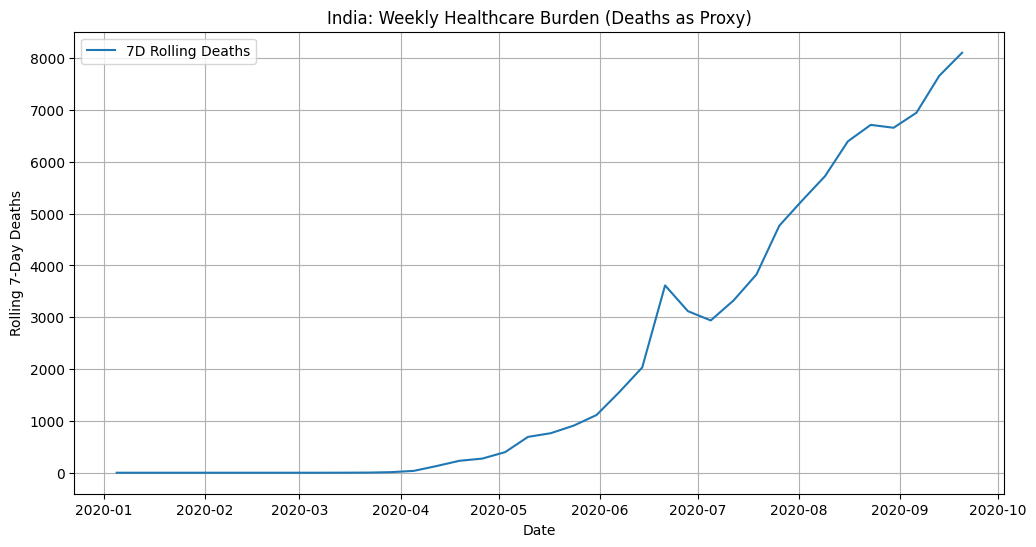

In [12]:
india = df[df["location"] == "India"]

plt.figure(figsize=(12,6))
plt.plot(india["date"], india["rolling_7d_deaths"], label="7D Rolling Deaths")
plt.title("India: Weekly Healthcare Burden (Deaths as Proxy)")
plt.ylabel("Rolling 7-Day Deaths")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.show()

In [13]:
print("### Key Insights from EDA ###\n")

print("1. Global peaks in cases and deaths occurred around:")
print("   - Peak Cases: ", peak_cases)
print("   - Peak Deaths:", peak_deaths)

print("\n2. Deaths per million show multiple waves, indicating recurring healthcare strain.")

print("\n3. Case Fatality Rate trends show improvements in some waves, likely due to:")
print("   - improved clinical knowledge\n"
      "   - increased hospital capacity\n"
      "   - younger population waves")

print("\n4. Countries with high burden tend to also have:")
print("   - higher aged_65_older\n"
      "   - lower hospital_beds_per_thousand\n"
      "   - higher population_density")

print("\n5. India's curve shows:")
print("   - clear peak during Delta\n"
      "   - multiple smaller waves\n"
      "   - strong fluctuations in 7-day rolling deaths (resource strain)")

### Key Insights from EDA ###

1. Global peaks in cases and deaths occurred around:
   - Peak Cases:  2020-09-06 00:00:00
   - Peak Deaths: 2020-04-19 00:00:00

2. Deaths per million show multiple waves, indicating recurring healthcare strain.

3. Case Fatality Rate trends show improvements in some waves, likely due to:
   - improved clinical knowledge
   - increased hospital capacity
   - younger population waves

4. Countries with high burden tend to also have:
   - higher aged_65_older
   - lower hospital_beds_per_thousand
   - higher population_density

5. India's curve shows:
   - clear peak during Delta
   - multiple smaller waves
   - strong fluctuations in 7-day rolling deaths (resource strain)
